# FER-2013 CNN Training


In [21]:
import os
import json
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import files


from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive

drive.mount("/content/drive")

DRIVE_DIR = Path("/content/drive/MyDrive/EmD")
LOCAL_DIR = Path("/content/fer2013")

CHECKPOINT_DIR = DRIVE_DIR / "cnn_checkpoints"
LATEST_MODEL = CHECKPOINT_DIR / "latest.keras"
BEST_MODEL = CHECKPOINT_DIR / "best.keras"
STATE_PATH = CHECKPOINT_DIR / "training_state.json"
LOG_PATH = CHECKPOINT_DIR / "training_log.csv"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Drive folder:", DRIVE_DIR)
print("Checkpoint folder:", CHECKPOINT_DIR)

Mounted at /content/drive
Drive folder: /content/drive/MyDrive/EmD
Checkpoint folder: /content/drive/MyDrive/EmD/cnn_checkpoints


In [3]:
def find_dataset_root(base):
    base = Path(base)

    if (base / "train").is_dir() and (base / "test").is_dir():
        return base

    for train_dir in base.rglob("train"):
        parent = train_dir.parent
        if (parent / "test").is_dir():
            return parent

    return None


drive_root = find_dataset_root(DRIVE_DIR)

if drive_root is not None:
    DATA_ROOT = drive_root
    print("Using extracted dataset:", DATA_ROOT)
else:
    zip_files = list(DRIVE_DIR.glob("*.zip"))

    if not zip_files:
        raise FileNotFoundError(
            "No FER-2013 train/test folders or ZIP file found inside MyDrive/EmD."
        )

    preferred = [p for p in zip_files if "fer" in p.name.lower()]
    ZIP_PATH = preferred[0] if preferred else zip_files[0]

    if not (LOCAL_DIR / "train").is_dir():
        LOCAL_DIR.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(ZIP_PATH, "r") as z:
            z.extractall(LOCAL_DIR)

    DATA_ROOT = find_dataset_root(LOCAL_DIR)

    if DATA_ROOT is None:
        raise FileNotFoundError("train and test folders were not found after extraction.")

    print("ZIP:", ZIP_PATH)
    print("Local dataset:", DATA_ROOT)

ZIP: /content/drive/MyDrive/EmD/FER-2013.zip
Local dataset: /content/fer2013


In [4]:
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"

extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

class_names = sorted([
    p.name for p in TRAIN_DIR.iterdir()
    if p.is_dir()
])

def image_count(folder):
    return sum(
        1 for p in Path(folder).rglob("*")
        if p.is_file() and p.suffix.lower() in extensions
    )

rows = []
for name in class_names:
    rows.append({
        "emotion": name,
        "train": image_count(TRAIN_DIR / name),
        "test": image_count(TEST_DIR / name)
    })

counts_df = pd.DataFrame(rows)
display(counts_df)
print("Classes:", class_names)
print("Total train:", counts_df["train"].sum())
print("Total test:", counts_df["test"].sum())

,emotion,train,test
0,angry,3995,958
1,disgust,436,111
2,fear,4097,1024
3,happy,7215,1774
4,neutral,4965,1233
5,sad,4830,1247
6,surprise,3171,831


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total train: 28709
Total test: 7178


In [5]:
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
VAL_SPLIT = 0.20

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print(class_names)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


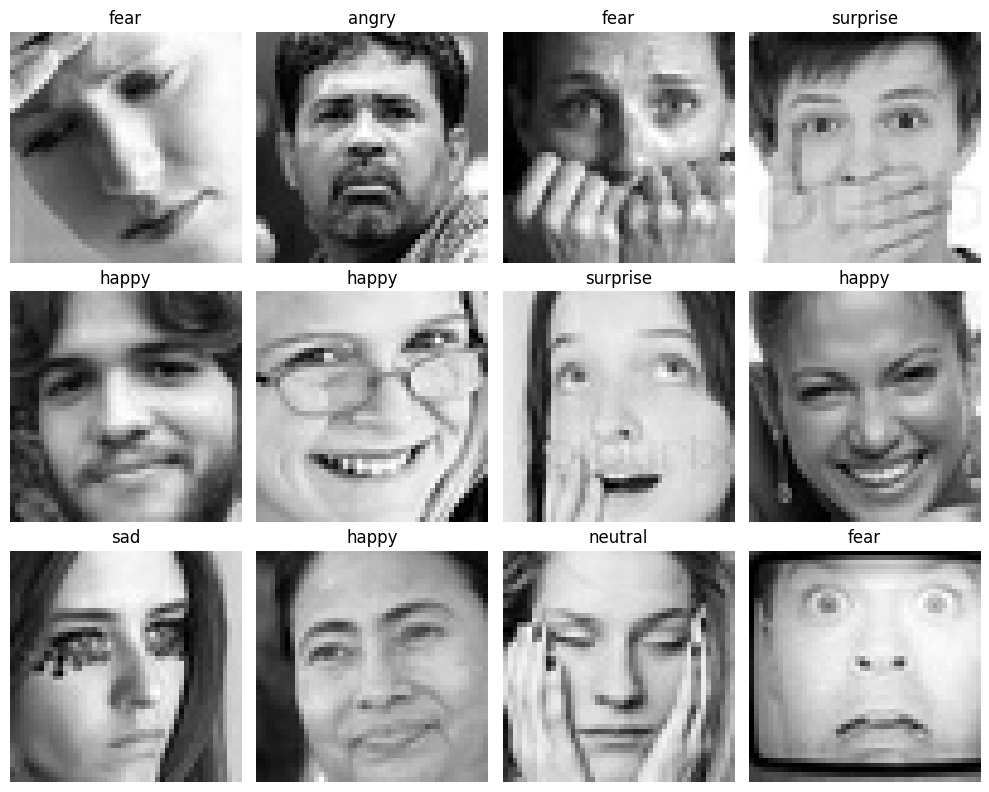

In [6]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(10, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().squeeze(), cmap="gray")
    plt.title(class_names[int(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
train_counts = {
    name: image_count(TRAIN_DIR / name)
    for name in class_names
}

total_images = sum(train_counts.values())
num_classes = len(class_names)

class_weight = {
    i: total_images / (num_classes * train_counts[name])
    for i, name in enumerate(class_names)
}

print(class_weight)

{0: 1.0266046844269623, 1: 9.406618610747051, 2: 1.0010460615781582, 3: 0.5684387684387684, 4: 0.8260394187886635, 5: 0.8491274770777877, 6: 1.293372978330405}


In [8]:
def build_model(num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(48, 48, 1)),

        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.Rescaling(1.0 / 255),

        tf.keras.layers.Conv2D(32, 3, padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(256, 3, padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.ReLU(),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model


model = build_model(num_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 48, 48, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             

 Total params: 423,559 (1.62 MB)

 Trainable params: 422,599 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## Resume setup

If Colab disconnects, reconnect and run the notebook again. It loads `latest.keras` and continues from the last completed epoch.

In [9]:
start_epoch = 0

if LATEST_MODEL.exists():
    model = tf.keras.models.load_model(LATEST_MODEL)

    if STATE_PATH.exists():
        with open(STATE_PATH, "r") as f:
            state = json.load(f)
        start_epoch = int(state.get("completed_epochs", 0))

    print(f"Loaded checkpoint. Resuming from epoch {start_epoch}.")
else:
    print("No checkpoint found. Starting fresh.")

No checkpoint found. Starting fresh.


In [10]:
class EpochState(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        with open(STATE_PATH, "w") as f:
            json.dump({"completed_epochs": epoch + 1}, f)


latest_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(LATEST_MODEL),
    save_best_only=False,
    save_freq="epoch",
    verbose=1
)

best_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(BEST_MODEL),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

if LOG_PATH.exists():
    old_log = pd.read_csv(LOG_PATH)
    if "val_accuracy" in old_log and len(old_log):
        best_checkpoint.best = float(old_log["val_accuracy"].max())

callbacks = [
    latest_checkpoint,
    best_checkpoint,
    tf.keras.callbacks.CSVLogger(
        str(LOG_PATH),
        append=start_epoch > 0
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    EpochState()
]

In [12]:
TOTAL_EPOCHS = 100

if start_epoch < TOTAL_EPOCHS:
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=TOTAL_EPOCHS,
        initial_epoch=start_epoch,
        class_weight=class_weight,
        callbacks=callbacks
    )
else:
    print(
        f"Training already reached {start_epoch} epochs. "
        "Increase TOTAL_EPOCHS to continue training."
    )

Epoch 1/100
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5222 - loss: 1.1998
Epoch 1: saving model to /content/drive/MyDrive/EmD/cnn_checkpoints/latest.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EmD/cnn_checkpoints/latest.keras

Epoch 1: val_accuracy improved from 0.54259 to 0.54381, saving model to /content/drive/MyDrive/EmD/cnn_checkpoints/best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/EmD/cnn_checkpoints/best.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.5236 - loss: 1.1947 - val_accuracy: 0.5438 - val_loss: 1.1784 - learning_rate: 2.5000e-04
Epoch 2/100
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5207 - loss: 1.1901
Epoch 2: saving model to /content/drive/MyDrive/EmD/cnn_checkpoints/latest.keras

Epoch 2: finished saving model to /content/drive/MyDrive/EmD/cnn_checkpoints/latest.keras

Epoch 2: val_accuracy did not improve from 0.54381
359/359 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5259 - lo

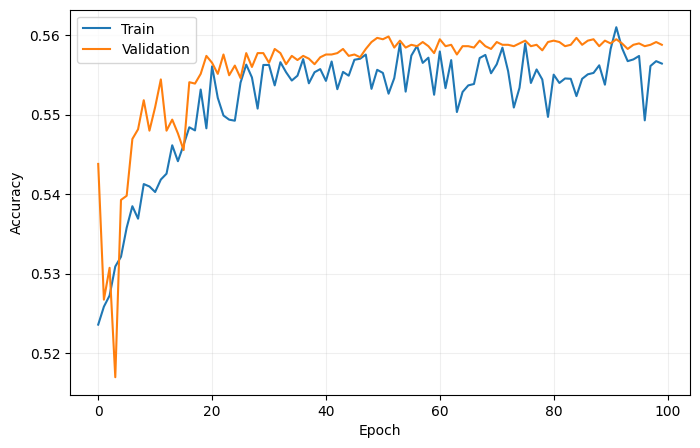

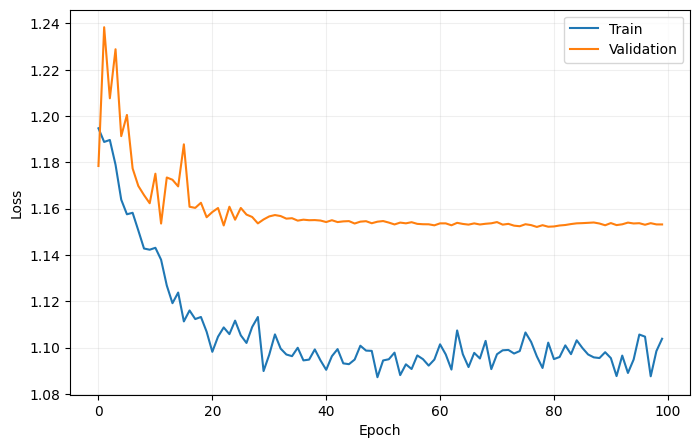

In [13]:
if LOG_PATH.exists():
    log_df = pd.read_csv(LOG_PATH)

    plt.figure(figsize=(8, 5))
    plt.plot(log_df["accuracy"], label="Train")
    plt.plot(log_df["val_accuracy"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(log_df["loss"], label="Train")
    plt.plot(log_df["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

## Test the trained model

In [14]:
model_path = BEST_MODEL if BEST_MODEL.exists() else LATEST_MODEL

if not model_path.exists():
    raise FileNotFoundError("Train the model first.")

test_model = tf.keras.models.load_model(model_path)

test_loss, test_accuracy = test_model.evaluate(test_ds, verbose=1)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5642 - loss: 1.1391
Test loss: 1.1391
Test accuracy: 0.5642


In [15]:
y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])

y_prob = test_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
              precision    recall  f1-score   support

       angry     0.4211    0.5511    0.4774       958
     disgust     0.3128    0.6847    0.4294       111
        fear     0.4246    0.1650    0.2377      1024
       happy     0.8457    0.7909    0.8174      1774
     neutral     0.4464    0.6991    0.5449      1233
         sad     0.4797    0.3320    0.3924      1247
    surprise     0.7205    0.7196    0.7200       831

    accuracy                         0.5642      7178
   macro avg     0.5215    0.5632    0.5170      7178
weighted avg     0.5740    0.5642    0.5514      7178



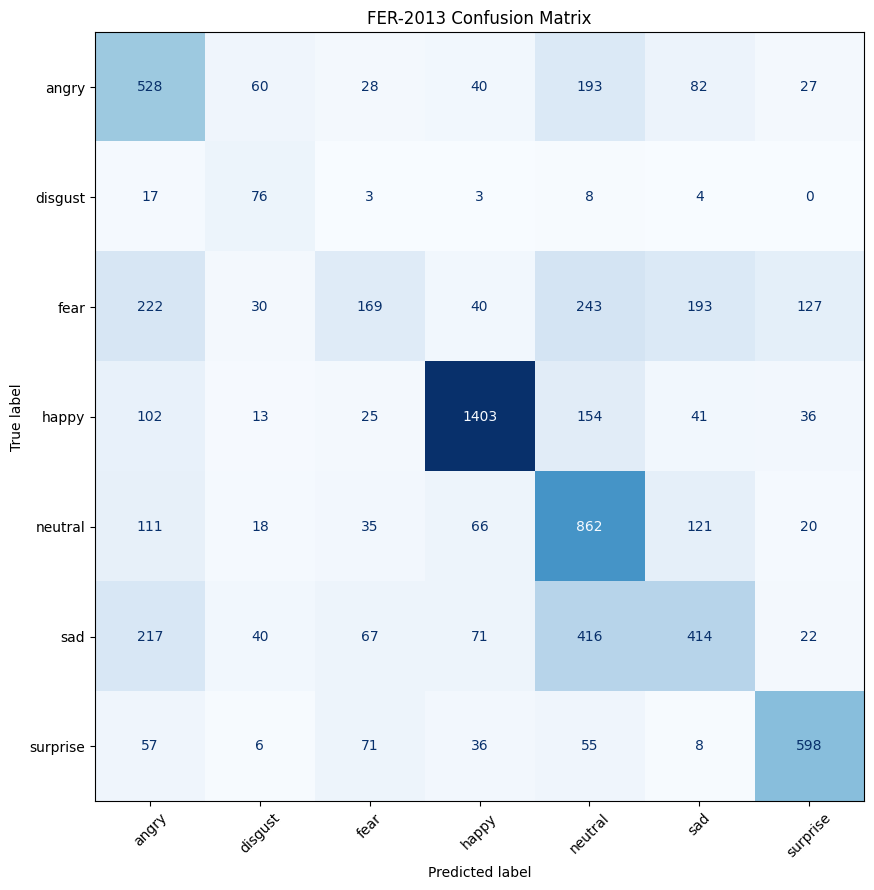

In [16]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 9))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.xticks(rotation=45)
plt.title("FER-2013 Confusion Matrix")
plt.tight_layout()
plt.show()

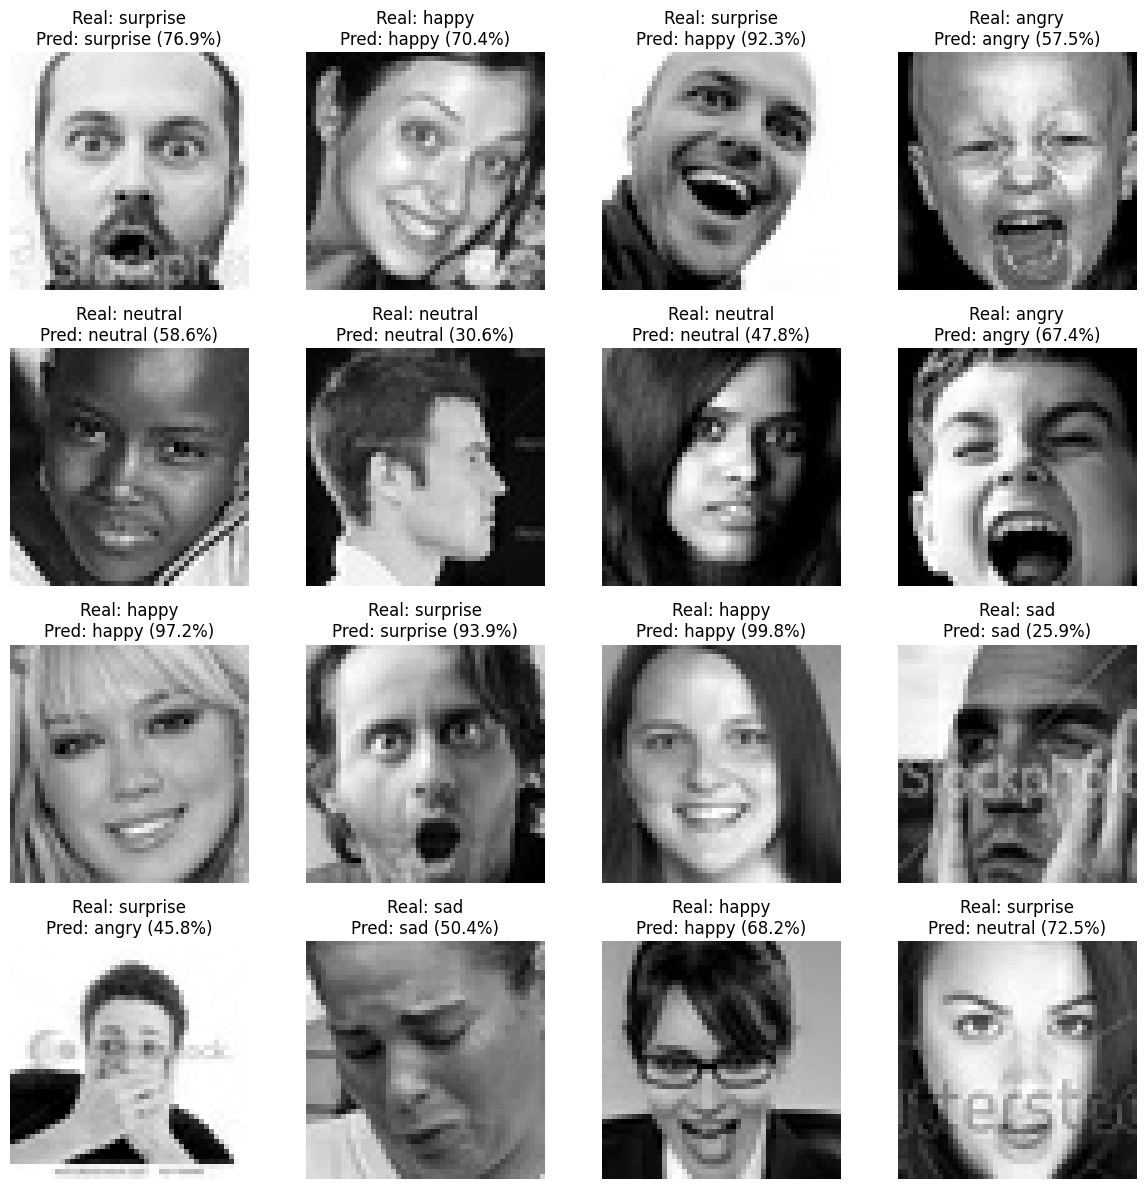

In [27]:
num_test_images = int(counts_df["test"].sum())

sample_ds = (
    test_ds
    .unbatch()
    .shuffle(
        buffer_size=num_test_images,
        reshuffle_each_iteration=True
    )
    .take(16)
    .batch(16)
)

sample_images, sample_labels = next(iter(sample_ds))

sample_probs = test_model.predict(
    sample_images,
    verbose=0
)

sample_preds = np.argmax(sample_probs, axis=1)

plt.figure(figsize=(12, 12))

for i in range(len(sample_images)):
    real_label = class_names[int(sample_labels[i])]
    predicted_label = class_names[int(sample_preds[i])]
    confidence = float(np.max(sample_probs[i])) * 100

    plt.subplot(4, 4, i + 1)

    plt.imshow(
        sample_images[i].numpy().squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Real: {real_label}\n"
        f"Pred: {predicted_label} ({confidence:.1f}%)"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
!pip install -q mediapipe

!wget -q -O /content/blaze_face_short_range.tflite \
https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 14.2 MB/s eta 0:00:00


In [36]:
from google.colab import files

import os
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

MODEL_PATH = "/content/blaze_face_short_range.tflite"

if not os.path.exists(MODEL_PATH):
    !wget -q -O /content/blaze_face_short_range.tflite \
    https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite


BaseOptions = mp.tasks.BaseOptions
FaceDetector = mp.tasks.vision.FaceDetector
FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions
RunningMode = mp.tasks.vision.RunningMode

options = FaceDetectorOptions(
    base_options=BaseOptions(
        model_asset_path=MODEL_PATH
    ),
    running_mode=RunningMode.IMAGE,
    min_detection_confidence=0.5
)


def predict_face(image_path, model=test_model):

    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        print("Could not load image.")
        return

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image_rgb
    )

    with FaceDetector.create_from_options(options) as detector:
        result = detector.detect(mp_image)

    if not result.detections:
        print("No face detected.")
        return

    detection = max(
        result.detections,
        key=lambda d:
        d.bounding_box.width *
        d.bounding_box.height
    )

    box = detection.bounding_box

    x = box.origin_x
    y = box.origin_y
    w = box.width
    h = box.height

    img_h, img_w = image_rgb.shape[:2]

    margin = 0.18

    center_x = x + w // 2
    center_y = y + h // 2

    size = int(
        max(w, h) *
        (1 + margin * 2)
    )

    x1 = max(
        center_x - size // 2,
        0
    )

    y1 = max(
        center_y - size // 2,
        0
    )

    x2 = min(
        center_x + size // 2,
        img_w
    )

    y2 = min(
        center_y + size // 2,
        img_h
    )

    face_rgb = image_rgb[
        y1:y2,
        x1:x2
    ]

    if face_rgb.size == 0:
        print("Face crop failed.")
        return

    face_gray = cv2.cvtColor(
        face_rgb,
        cv2.COLOR_RGB2GRAY
    )

    face_gray = cv2.resize(
        face_gray,
        IMG_SIZE,
        interpolation=cv2.INTER_AREA
    )

    x_input = face_gray.astype(
        np.float32
    )

    x_input = np.expand_dims(
        x_input,
        axis=-1
    )

    x_input = np.expand_dims(
        x_input,
        axis=0
    )

    probs = model.predict(
        x_input,
        verbose=0
    )[0]

    index = int(
        np.argmax(probs)
    )

    predicted_label = class_names[index]

    confidence = (
        float(probs[index]) * 100
    )

    display_image = image_rgb.copy()

    cv2.rectangle(
        display_image,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        3
    )

    plt.figure(
        figsize=(12, 4)
    )

    plt.subplot(1, 3, 1)

    plt.imshow(
        display_image
    )

    plt.title("Detected Face")
    plt.axis("off")


    plt.subplot(1, 3, 2)

    plt.imshow(
        face_rgb
    )

    plt.title("Cropped Face")
    plt.axis("off")


    plt.subplot(1, 3, 3)

    plt.imshow(
        face_gray,
        cmap="gray"
    )

    plt.title(
        f"{IMG_SIZE[0]}×{IMG_SIZE[1]} Grayscale"
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()


    print(
        "Predicted emotion:",
        predicted_label
    )

    print(
        f"Confidence: {confidence:.2f}%"
    )


    print("\nAll probabilities:")

    for name, probability in zip(
        class_names,
        probs
    ):

        print(
            f"{name:10s}: "
            f"{probability * 100:.2f}%"
        )

    return predicted_label, confidence


def upload_and_predict(model=test_model):

    uploaded = files.upload()

    for filename in uploaded.keys():

        print(
            f"\nImage: {filename}"
        )

        predict_face(
            filename,
            model=model
        )

Saving images.jpg to images (3).jpg

Image: images (3).jpg


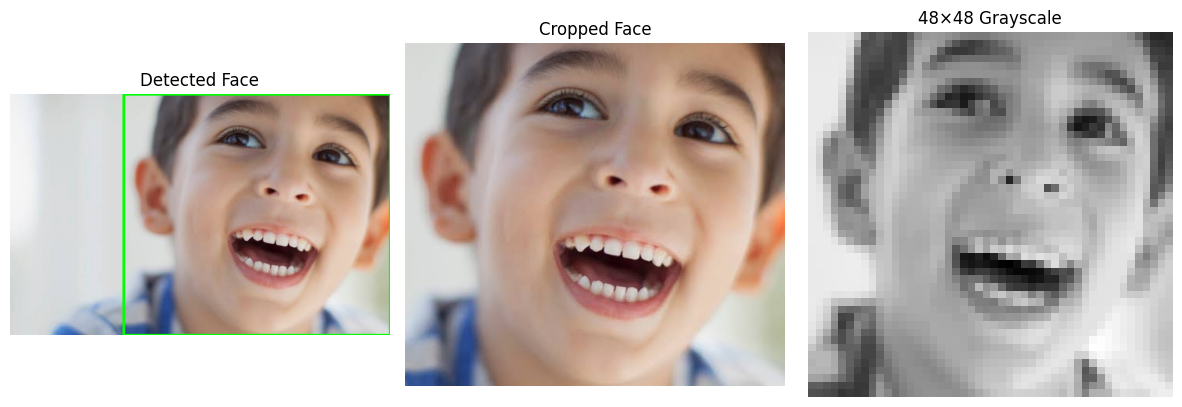

Predicted emotion: happy
Confidence: 79.98%

All probabilities:
angry     : 9.69%
disgust   : 0.00%
fear      : 2.92%
happy     : 79.98%
neutral   : 4.28%
sad       : 1.67%
surprise  : 1.45%


In [38]:
upload_and_predict()

Saving images (1).jpg to images (1) (2).jpg

Image: images (1) (2).jpg


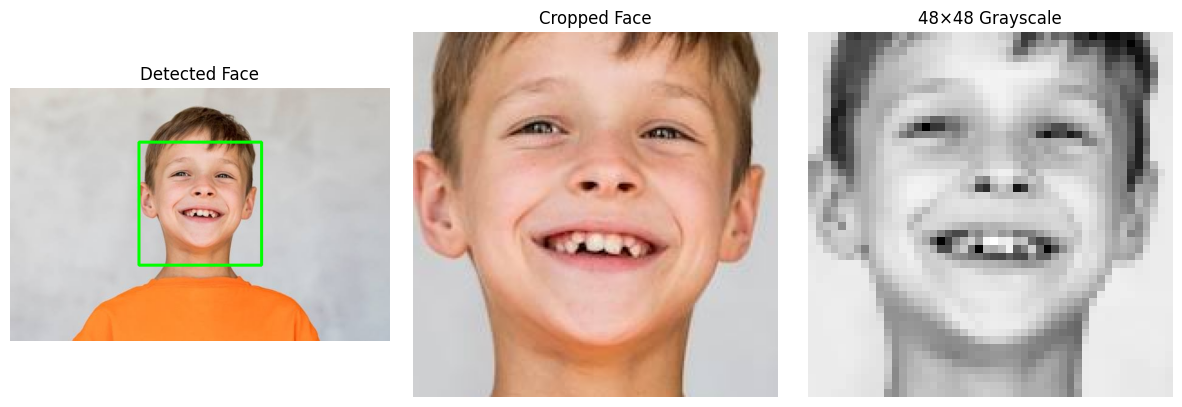

Predicted emotion: happy
Confidence: 89.65%

All probabilities:
angry     : 0.96%
disgust   : 0.00%
fear      : 1.23%
happy     : 89.65%
neutral   : 4.99%
sad       : 0.95%
surprise  : 2.23%


In [39]:
upload_and_predict()

Saving istockphoto-1045297442-612x612.jpg to istockphoto-1045297442-612x612 (1).jpg

Image: istockphoto-1045297442-612x612 (1).jpg


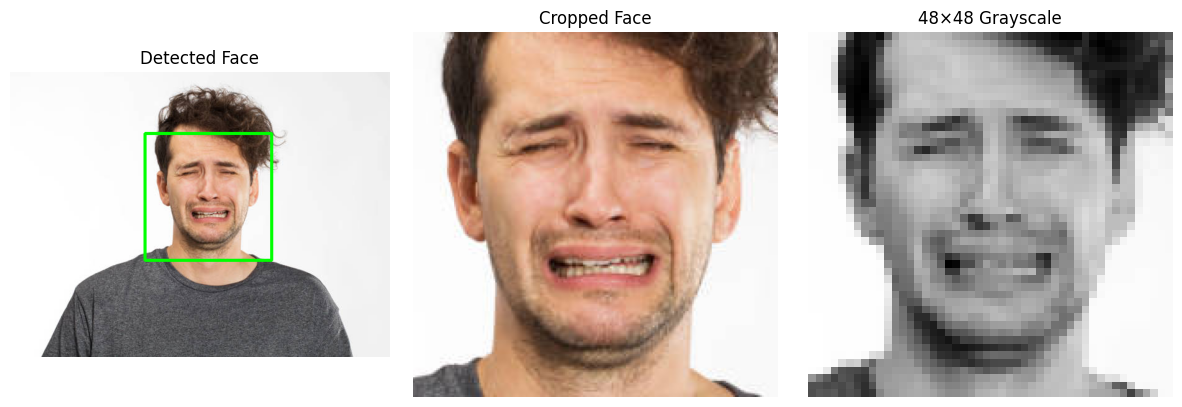

Predicted emotion: happy
Confidence: 72.27%

All probabilities:
angry     : 3.92%
disgust   : 0.07%
fear      : 2.50%
happy     : 72.27%
neutral   : 15.09%
sad       : 5.61%
surprise  : 0.54%


In [40]:
upload_and_predict()

Saving adorable-little-girl-sad-expression-her-face-going-to-cry-unhappy-118423817.webp to adorable-little-girl-sad-expression-her-face-going-to-cry-unhappy-118423817 (1).webp

Image: adorable-little-girl-sad-expression-her-face-going-to-cry-unhappy-118423817 (1).webp


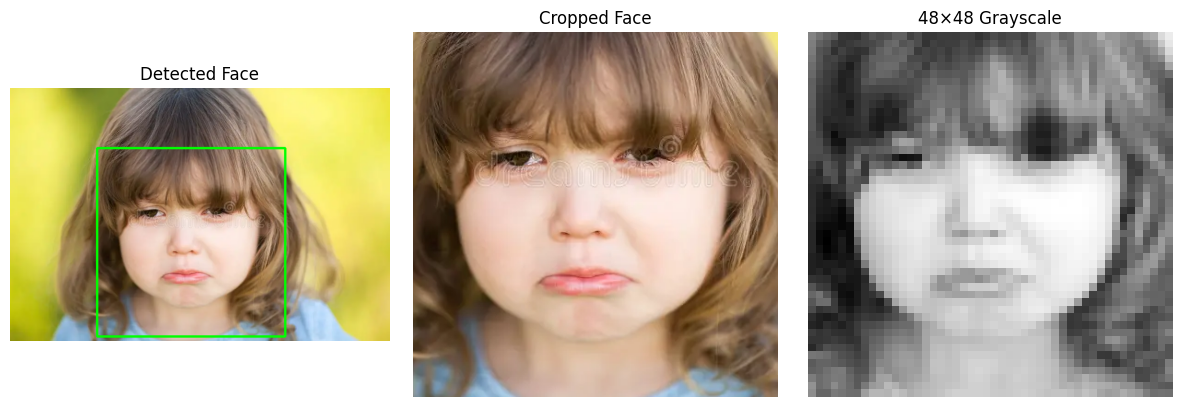

Predicted emotion: neutral
Confidence: 45.35%

All probabilities:
angry     : 16.06%
disgust   : 3.51%
fear      : 10.04%
happy     : 1.21%
neutral   : 45.35%
sad       : 22.99%
surprise  : 0.83%


In [41]:
upload_and_predict()

Saving 583eb5ef7abbdd4f80452b6722393028.jpg to 583eb5ef7abbdd4f80452b6722393028 (1).jpg

Image: 583eb5ef7abbdd4f80452b6722393028 (1).jpg


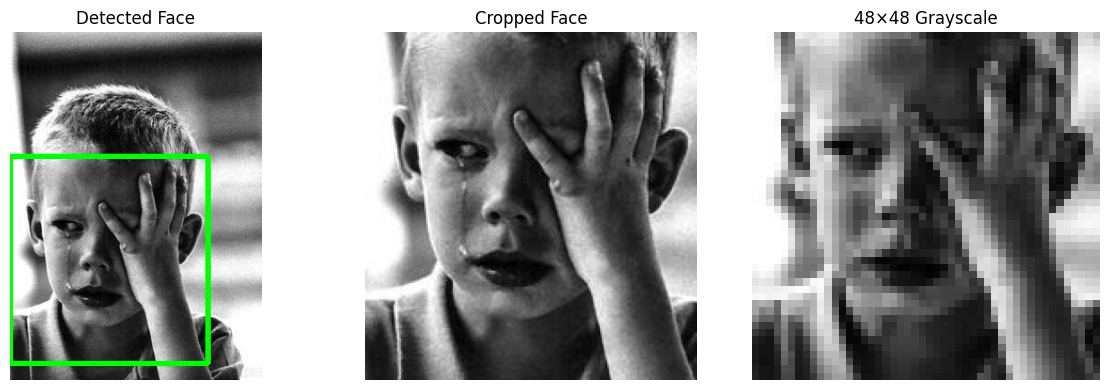

Predicted emotion: sad
Confidence: 53.11%

All probabilities:
angry     : 7.79%
disgust   : 0.01%
fear      : 24.40%
happy     : 1.26%
neutral   : 12.79%
sad       : 53.11%
surprise  : 0.65%


In [42]:
upload_and_predict()

Saving depositphotos_201294566-stock-photo-afraid-touch-portrait-scared-woman.jpg to depositphotos_201294566-stock-photo-afraid-touch-portrait-scared-woman.jpg

Image: depositphotos_201294566-stock-photo-afraid-touch-portrait-scared-woman.jpg


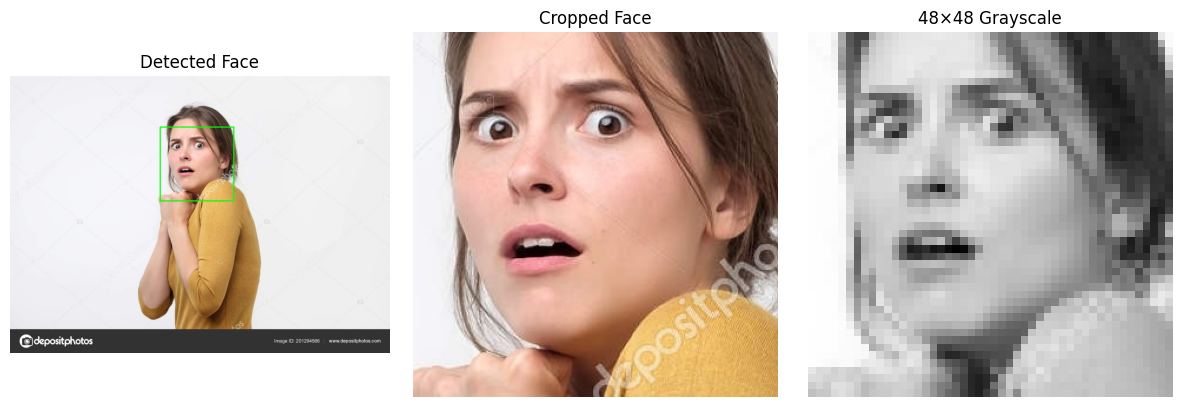

Predicted emotion: happy
Confidence: 32.47%

All probabilities:
angry     : 8.28%
disgust   : 0.08%
fear      : 12.34%
happy     : 32.47%
neutral   : 14.79%
sad       : 6.90%
surprise  : 25.14%


In [37]:
upload_and_predict()

Saving how-to-calm-an-angry-child-photo.jpg to how-to-calm-an-angry-child-photo (1).jpg

Image: how-to-calm-an-angry-child-photo (1).jpg


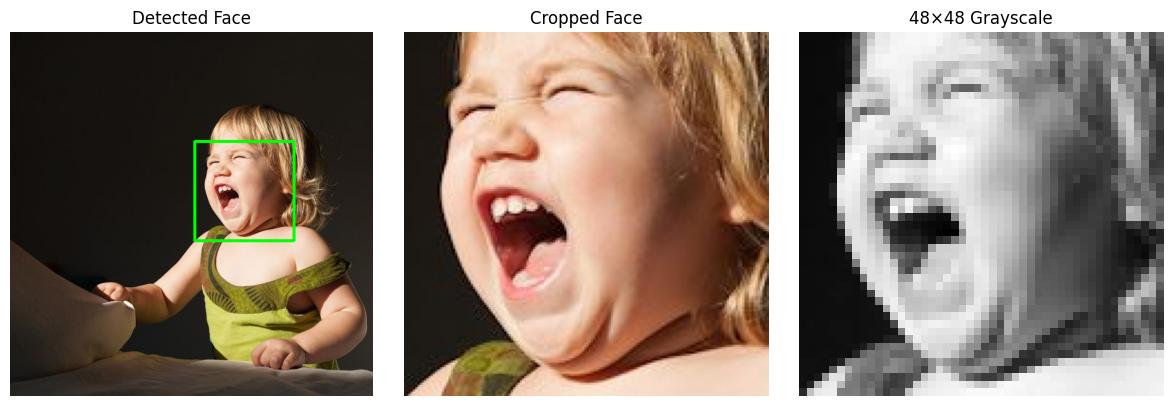

Predicted emotion: angry
Confidence: 31.75%

All probabilities:
angry     : 31.75%
disgust   : 0.02%
fear      : 13.04%
happy     : 24.25%
neutral   : 11.17%
sad       : 18.84%
surprise  : 0.93%


In [43]:
upload_and_predict()

Saving premium_photo-1697398289867-ad4e8de16b66.avif to premium_photo-1697398289867-ad4e8de16b66 (1).avif

Image: premium_photo-1697398289867-ad4e8de16b66 (1).avif


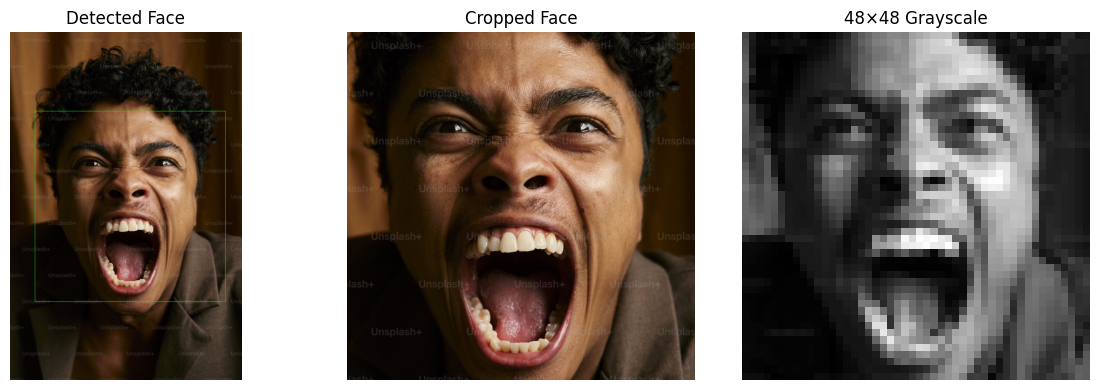

Predicted emotion: angry
Confidence: 72.36%

All probabilities:
angry     : 72.36%
disgust   : 0.10%
fear      : 15.80%
happy     : 9.13%
neutral   : 0.25%
sad       : 1.16%
surprise  : 1.19%


In [44]:
upload_and_predict()

Saving portrait-young-latin-woman-feeling-scared-shocked-making-fear-anxiety-gestures-looking-terrified-covering-herself-copy-156838537.webp to portrait-young-latin-woman-feeling-scared-shocked-making-fear-anxiety-gestures-looking-terrified-covering-herself-copy-156838537.webp

Image: portrait-young-latin-woman-feeling-scared-shocked-making-fear-anxiety-gestures-looking-terrified-covering-herself-copy-156838537.webp


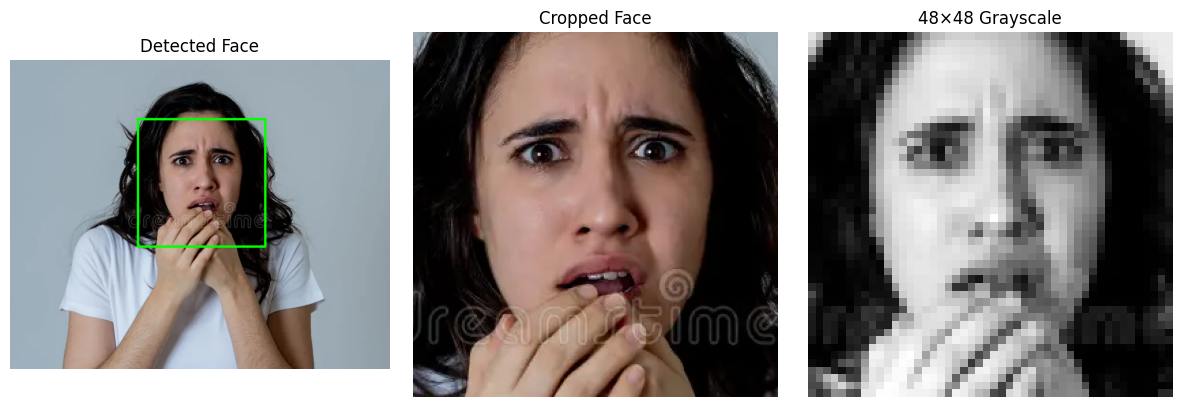

Predicted emotion: fear
Confidence: 49.65%

All probabilities:
angry     : 24.68%
disgust   : 0.04%
fear      : 49.65%
happy     : 0.23%
neutral   : 6.47%
sad       : 16.56%
surprise  : 2.37%


In [46]:
upload_and_predict()